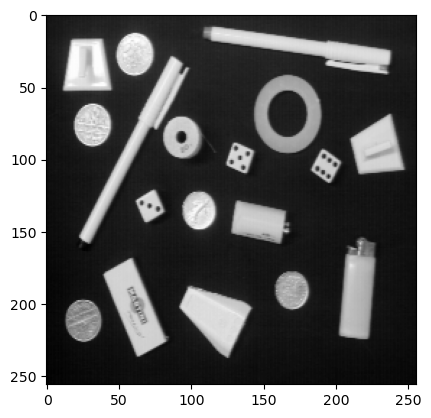

In [53]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/OBJECTS.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray")
plt.show()

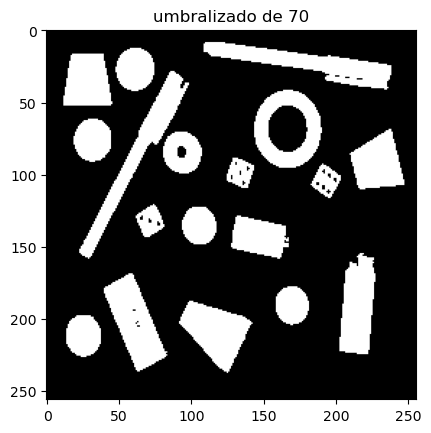

In [54]:
# Umbralice esta imagen para separar los objetos del fondo (umbral=70).

retval, umbralizado = cv2.threshold(image, 70, 255, cv2.THRESH_BINARY)

plt.imshow(umbralizado, cmap="gray")
plt.title("umbralizado de 70")
plt.show()

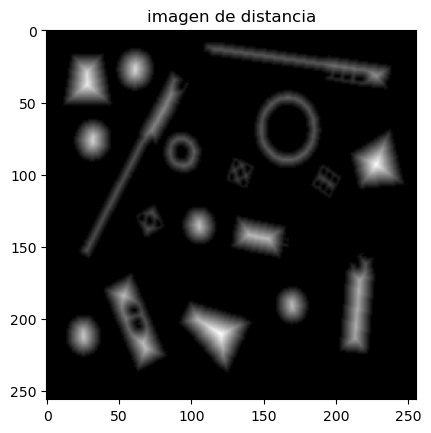

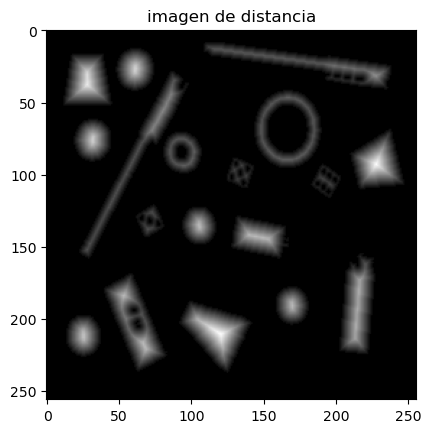

In [55]:
#Calcule la imagen de distancia. Puede efectuar una expansión del contraste sobre la imagen de distancia para visualizar mejor el resultado. Ajuste el Window/Level.

from scipy.ndimage import distance_transform_edt
import numpy as np

edm = distance_transform_edt(umbralizado)

plt.imshow(edm, cmap="gray")
plt.title("imagen de distancia")
plt.show()

# Expansion del contraste
from skimage import exposure

rescaled_img = exposure.rescale_intensity(edm, in_range=(edm.min(),edm.max()), out_range=(0,255))
rescaled_img = rescaled_img.astype(np.uint8)
plt.imshow(rescaled_img, cmap="gray", vmin=0, vmax=255)
plt.title("imagen de distancia")
plt.show()

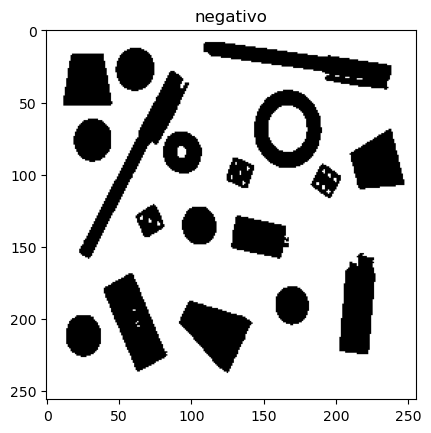

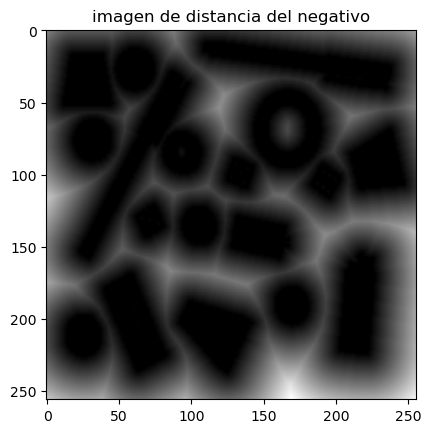

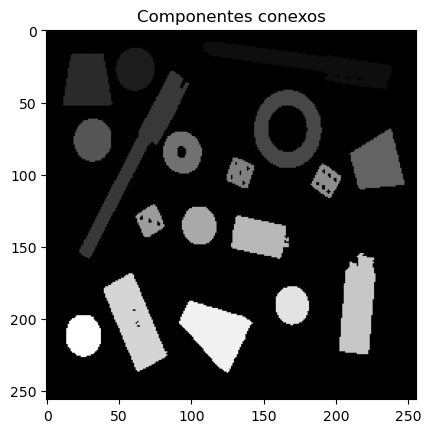

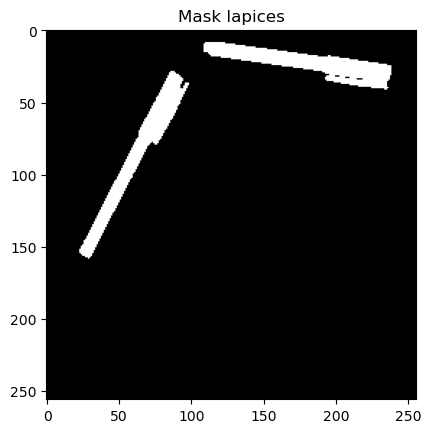

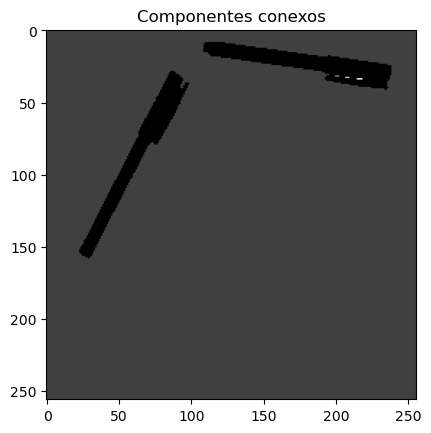

[[  0   0]
 [  0   1]
 [  0   2]
 ...
 [255 253]
 [255 254]
 [255 255]]
[[ 32 200]
 [ 32 201]
 [ 32 202]]
Distancia mínima entre lápices: 4.47213595499958


In [56]:
#Calcule ahora el negativo de la imagen umbralizada del punto 3.
# Ahora realice el cálculo de la distancia euclidiana.
# Utilizando la imagen resultante, determine la distancia mínima entre los dos lápices.
# Utilice máscaras y operaciones sobre pixeles para determinar el valor del pixel en el mapa de distancias a medio camino entre la distancia mínima de los dos lápices.

#Calcule ahora el negativo de la imagen umbralizada del punto 3.
negativo = cv2.bitwise_not(umbralizado)

plt.imshow(negativo, cmap="gray")
plt.title("negativo")
plt.show()

# Ahora realice el cálculo de la distancia euclidiana.
edm_negativo = distance_transform_edt(negativo)

plt.imshow(edm_negativo, cmap="gray")
plt.title("imagen de distancia del negativo")
plt.show()

# Utilizando la imagen resultante, determine la distancia mínima entre los dos lápices.

# Primero etiqueto los objetos
from skimage.measure import label, regionprops
from scipy.spatial.distance import cdist


connected_components = label(umbralizado, background=0, connectivity=2)

plt.imshow(connected_components, cmap="gray")
plt.title("Componentes conexos")
plt.show()

regions = regionprops(connected_components)

# Mascara de lapices
mask_lapices = np.zeros_like(umbralizado)

for r in regions:
    if r.eccentricity > 0.97:   # objetos muy alargados
        mask_lapices[connected_components == r.label] = 255
        
plt.imshow(mask_lapices, cmap="gray", vmin=0, vmax=255)
plt.title("Mask lapices")
plt.show()

inverted_mask = cv2.bitwise_not(mask_lapices)

# etiqueto objetos de la mascara
connected_components = label(inverted_mask, background=0, connectivity=2)
regions = regionprops(connected_components)

plt.imshow(connected_components, cmap="gray")
plt.title("Componentes conexos")
plt.show()

coords1 = regions[0].coords
coords2 = regions[1].coords

print(coords1)
print(coords2)

distances = cdist(coords1, coords2)

dist_min = np.min(distances)

print("Distancia mínima entre lápices:", dist_min)